# Notebook - Predicción de ocurrencia de accidentes

Este notebook evalúa la **ocurrencia anual** de accidentes en Bogotá. La unidad de análisis es:

**`ANIO + ZONA_CIUDAD + MES + DIA_SEMANA + HORA`**

`DATASET_OCURRENCIA.csv` contiene una cuadrícula completa por cada año disponible, las 150 zonas geográficas, la variable objetivo y el clima promedio del mismo año y patrón temporal.

> **Nota:** el modelo clasifica combinaciones anuales con base en la información histórica disponible. La evaluación temporal permite medir generalización hacia años posteriores, pero el score no debe interpretarse como una probabilidad individual de accidente por viaje porque no se dispone de exposición vehicular y el ajuste utiliza una muestra de negativos.

## 1. Librerías y configuración

In [19]:
import json
import time
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

## 2. Carga del dataset

Se utiliza directamente `DATASET_OCURRENCIA.csv`. El notebook asume que este archivo ya contiene la asignación de las 150 zonas y las variables meteorológicas de cada combinación recurrente.

In [20]:
# Carga en Kaggle (dejar comentada si se ejecuta localmente)
# RUTA_DATOS = Path('/kaggle/input/datasets/caalsial/dataset-ocurrencia/DATASET_OCURRENCIA.csv')

# Carga local desde la carpeta modelo/
RUTA_DATOS = Path('../data/data_procesada/modelado/DATASET_OCURRENCIA.csv')

df = pd.read_csv(RUTA_DATOS)
print(f'Filas: {len(df):,}')
print(f'Columnas: {df.shape[1]}')
display(df.head())

Filas: 5,745,600
Columnas: 17


,ANIO,MES,DIA_SEMANA,HORA,ZONA_CIUDAD,LATITUD_CENTROIDE,LONGITUD_CENTROIDE,TEMPERATURA_2M,HUMEDAD_RELATIVA_2M,SENSACION_TERMICA,PRECIPITACION,LLUVIA,NUBOSIDAD,PRESION_SUPERFICIE,VELOCIDAD_VIENTO_10M,DIRECCION_VIENTO_10M,OCURRIO_ACCIDENTE
0,2007,1,0,0,0,4.6168,-74.1396,13.4400,85.6000,13.2000,0.0600,0.0600,77.2000,754.9600,4.3800,99.9985,0
1,2007,1,0,1,0,4.6168,-74.1396,13.1200,85.8000,12.7800,0.1400,0.1400,75.0000,754.2600,4.2600,100.0086,0
2,2007,1,0,2,0,4.6168,-74.1396,12.3800,88.0000,11.9600,0.0000,0.0000,73.8000,753.4000,4.3600,101.4123,0
3,2007,1,0,3,0,4.6168,-74.1396,11.8000,88.4000,11.2400,0.0000,0.0000,71.8000,752.6200,4.2400,102.1887,0
4,2007,1,0,4,0,4.6168,-74.1396,11.7000,87.8000,11.0200,0.0000,0.0000,71.6000,752.6400,4.6000,100.8068,0


## 2.1 Validaciones estructurales

Antes de entrenar se comprueba que exista una única fila por combinación anual. Para cada año se esperan:

`150 × 12 × 7 × 24 = 302.400` filas.

El total esperado depende de la cantidad de años completos incluidos en el archivo.

In [21]:
CLAVES = ['ANIO', 'ZONA_CIUDAD', 'MES', 'DIA_SEMANA', 'HORA']
TARGET = 'OCURRIO_ACCIDENTE'

VARIABLES_CLIMA_ORIGINALES = [
    'TEMPERATURA_2M', 'HUMEDAD_RELATIVA_2M', 'SENSACION_TERMICA',
    'PRECIPITACION', 'LLUVIA', 'NUBOSIDAD', 'PRESION_SUPERFICIE',
    'VELOCIDAD_VIENTO_10M', 'DIRECCION_VIENTO_10M'
]

COLUMNAS_REQUERIDAS = CLAVES + [
    'LATITUD_CENTROIDE', 'LONGITUD_CENTROIDE',
    *VARIABLES_CLIMA_ORIGINALES,
    TARGET
]

faltantes = [c for c in COLUMNAS_REQUERIDAS if c not in df.columns]
assert not faltantes, f'Faltan columnas requeridas: {faltantes}'
assert not df.duplicated(CLAVES).any(), 'Existen combinaciones recurrentes duplicadas.'
assert set(df[TARGET].dropna().unique()).issubset({0, 1}), 'El target debe ser binario.'
assert df['ZONA_CIUDAD'].nunique() == 150, 'Se esperaban 150 zonas geográficas.'

anios_disponibles = sorted(df['ANIO'].unique())
filas_por_anio = df['ZONA_CIUDAD'].nunique() * 12 * 7 * 24
filas_esperadas = len(anios_disponibles) * filas_por_anio
print(f'Filas observadas : {len(df):,}')
print(f'Filas esperadas  : {filas_esperadas:,}')
print(f'Años             : {min(anios_disponibles)}–{max(anios_disponibles)}')
print(f'Zonas            : {df.ZONA_CIUDAD.nunique()}')
print(f'Duplicados clave : {df.duplicated(CLAVES).sum():,}')

Filas observadas : 5,745,600
Filas esperadas  : 5,745,600
Años             : 2007–2025
Zonas            : 150
Duplicados clave : 0


## 2.2 Calidad de datos y prevalencia

La prevalencia se revisa antes de cualquier separación. Este valor también servirá para interpretar correctamente el F1 y construir la línea base.

In [22]:
resumen_target = (
    df[TARGET]
    .value_counts(dropna=False)
    .rename_axis(TARGET)
    .to_frame('FILAS')
)
resumen_target['PROPORCION'] = resumen_target['FILAS'] / len(df)
display(resumen_target)

print(f'Prevalencia positiva: {df[TARGET].mean():.4%}')

nulos = df.isna().sum().sort_values(ascending=False)
nulos = nulos[nulos.gt(0)].to_frame('NULOS')

,FILAS,PROPORCION
OCURRIO_ACCIDENTE,,
0,5286332,0.9201
1,459268,0.0799


Prevalencia positiva: 7.9934%


## 2.3 Centroides de las zonas

In [23]:
centroides_df = (
    df[['ZONA_CIUDAD', 'LATITUD_CENTROIDE', 'LONGITUD_CENTROIDE']]
    .drop_duplicates('ZONA_CIUDAD')
    .sort_values('ZONA_CIUDAD')
    .reset_index(drop=True)
)

assert len(centroides_df) == 150
display(centroides_df.head())

,ZONA_CIUDAD,LATITUD_CENTROIDE,LONGITUD_CENTROIDE
0,0,4.6168,-74.1396
1,1,4.6824,-74.0485
2,2,4.6944,-74.1105
3,3,4.5646,-74.1040
4,4,4.6227,-74.0705


## 2.4 Estadísticas descriptivas

In [24]:
resumen_tipos = pd.DataFrame({
    'TIPO': df.dtypes.astype(str),
    'NO_NULOS': df.notna().sum(),
    'VALORES_UNICOS': df.nunique(dropna=False),
})
display(resumen_tipos)

,TIPO,NO_NULOS,VALORES_UNICOS
ANIO,int64,5745600,19
MES,int64,5745600,12
DIA_SEMANA,int64,5745600,7
HORA,int64,5745600,24
ZONA_CIUDAD,int64,5745600,150
LATITUD_CENTROIDE,float64,5745600,150
LONGITUD_CENTROIDE,float64,5745600,150
TEMPERATURA_2M,float64,5745600,2353
HUMEDAD_RELATIVA_2M,float64,5745600,697
SENSACION_TERMICA,float64,5745600,2614


In [25]:
descriptivas_numericas = df.describe().T
display(descriptivas_numericas)

,count,mean,std,min,25%,50%,75%,max
ANIO,5745600.0000,2016.0000,5.4772,2007.0000,2011.0000,2016.0000,2021.0000,2025.0000
MES,5745600.0000,6.5000,3.4521,1.0000,3.7500,6.5000,9.2500,12.0000
DIA_SEMANA,5745600.0000,3.0000,2.0000,0.0000,1.0000,3.0000,5.0000,6.0000
HORA,5745600.0000,11.5000,6.9222,0.0000,5.7500,11.5000,17.2500,23.0000
ZONA_CIUDAD,5745600.0000,74.5000,43.3003,0.0000,37.0000,74.5000,112.0000,149.0000
LATITUD_CENTROIDE,5745600.0000,4.6527,0.0631,4.4922,4.6061,4.6537,4.6980,4.8126
LONGITUD_CENTROIDE,5745600.0000,-74.1015,0.0415,-74.2034,-74.1307,-74.1000,-74.0692,-74.0251
TEMPERATURA_2M,5745600.0000,13.6435,3.3928,2.2750,11.0250,13.0600,16.6000,24.9600
HUMEDAD_RELATIVA_2M,5745600.0000,78.7627,16.2581,19.0000,65.6000,84.2000,92.8000,100.0000
SENSACION_TERMICA,5745600.0000,12.8157,3.5717,-0.2750,10.1750,12.5000,15.6250,24.0000


## 2.5 Distribución de las variables numéricas

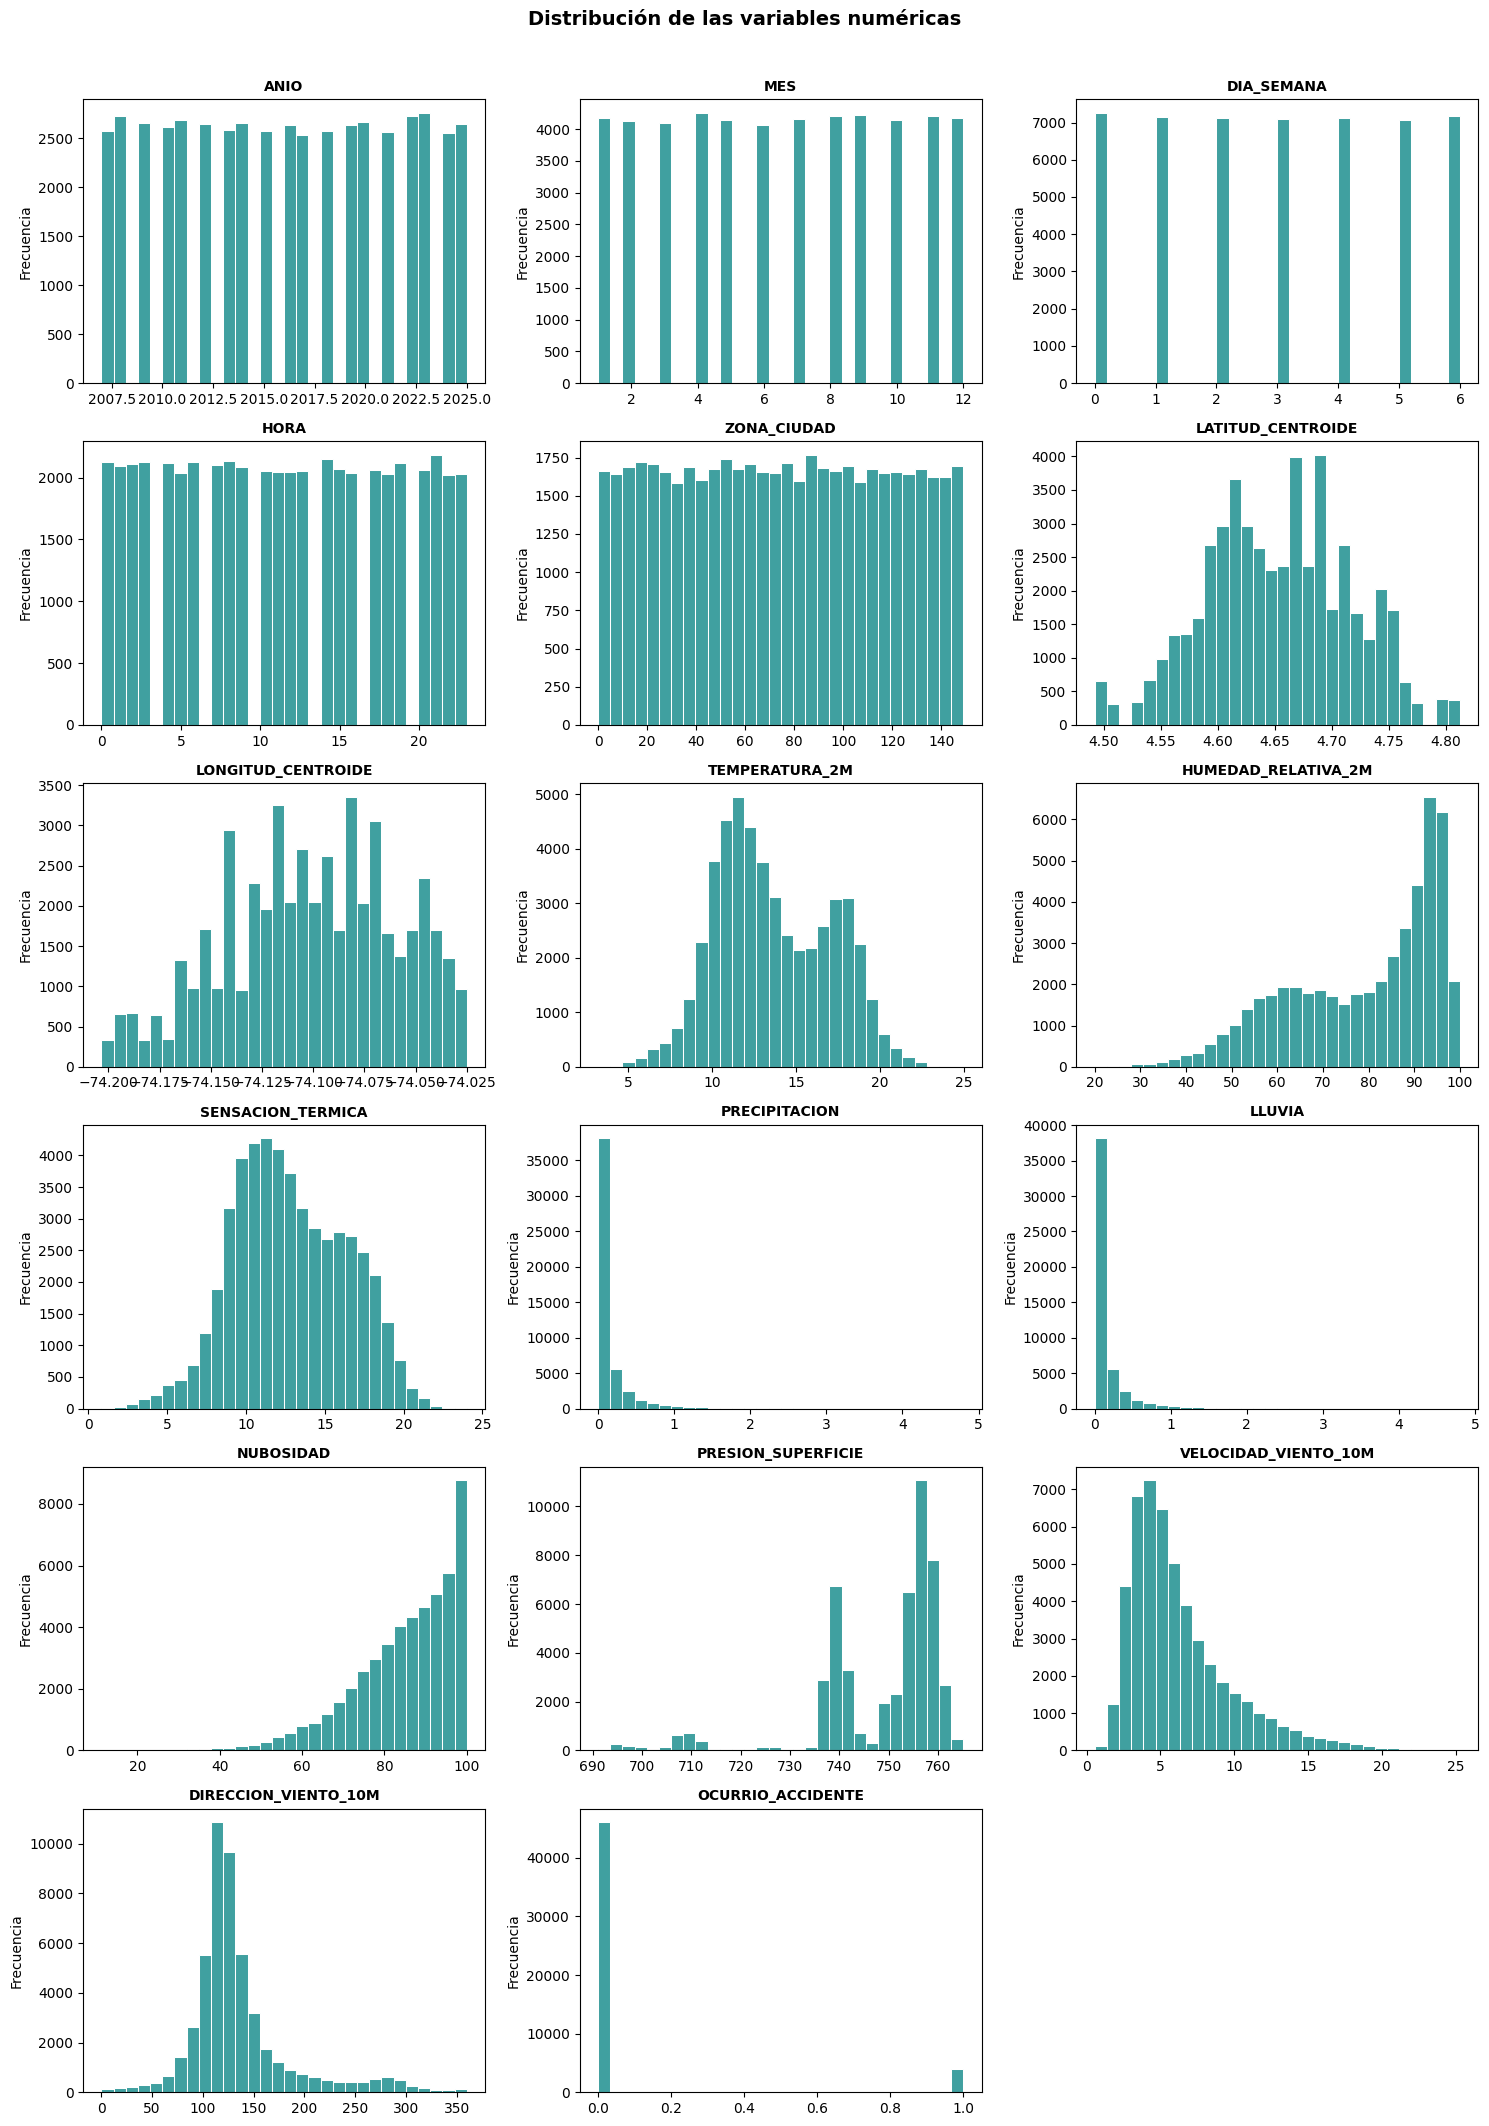

In [26]:
import seaborn as sns

columnas_numericas = df.select_dtypes(include='number').columns.tolist()
muestra_graficas = df.sample(
    n=min(50_000, len(df)),
    random_state=RANDOM_STATE
)

columnas_por_fila = 3
filas_grafica = int(np.ceil(len(columnas_numericas) / columnas_por_fila))
fig, ejes = plt.subplots(
    filas_grafica,
    columnas_por_fila,
    figsize=(15, 3.5 * filas_grafica)
)

ejes = np.asarray(ejes).reshape(-1)
for eje, columna in zip(ejes, columnas_numericas):
    sns.histplot(
        data=muestra_graficas,
        x=columna,
        bins=30,
        color='teal',
        edgecolor='white',
        ax=eje
    )
    eje.set_title(columna, fontsize=10, weight='bold')
    eje.set_xlabel('')
    eje.set_ylabel('Frecuencia')

for eje in ejes[len(columnas_numericas):]:
    eje.set_visible(False)

plt.suptitle('Distribución de las variables numéricas', fontsize=14, weight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 2.6 Correlación entre variables

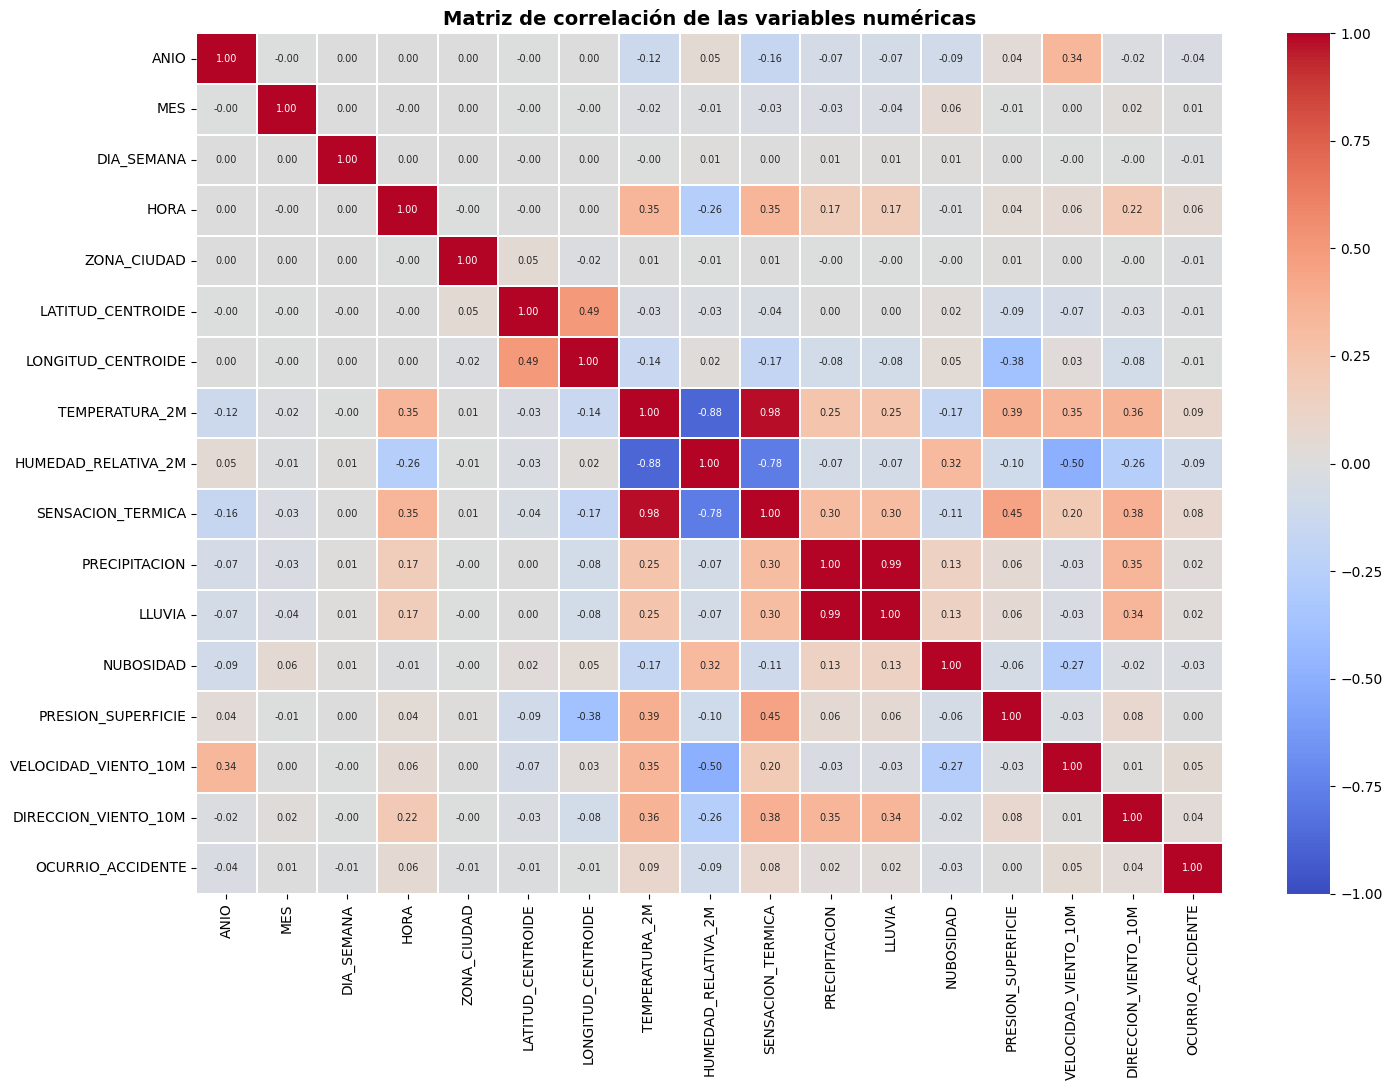

In [27]:
correlaciones = df[columnas_numericas].corr()

plt.figure(figsize=(15, 11))
sns.heatmap(
    correlaciones,
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 7},
    linewidths=0.3
)
plt.title('Matriz de correlación de las variables numéricas', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

## 2.7 Selección de variables meteorológicas por correlación

In [28]:
UMBRAL_CORRELACION = 0.80

decisiones_correlacion = pd.DataFrame([
    {
        'VARIABLE_CONSERVADA': 'TEMPERATURA_2M',
        'VARIABLE_RETIRADA': 'SENSACION_TERMICA',
        'JUSTIFICACION': 'Se conserva la medición directa de temperatura.'
    },
    {
        'VARIABLE_CONSERVADA': 'PRECIPITACION',
        'VARIABLE_RETIRADA': 'LLUVIA',
        'JUSTIFICACION': 'Se conserva precipitación como medida meteorológica directa.'
    },
    {
        'VARIABLE_CONSERVADA': 'TEMPERATURA_2M',
        'VARIABLE_RETIRADA': 'HUMEDAD_RELATIVA_2M',
        'JUSTIFICACION': 'Se prioriza temperatura por su interpretación operativa directa.'
    }
])

decisiones_correlacion['CORRELACION'] = decisiones_correlacion.apply(
    lambda fila: correlaciones.loc[
        fila['VARIABLE_CONSERVADA'], fila['VARIABLE_RETIRADA']
    ],
    axis=1
)
decisiones_correlacion['CORRELACION_ABSOLUTA'] = (
    decisiones_correlacion['CORRELACION'].abs()
)
decisiones_correlacion['SUPERA_UMBRAL'] = (
    decisiones_correlacion['CORRELACION_ABSOLUTA'] >= UMBRAL_CORRELACION
)

assert decisiones_correlacion['SUPERA_UMBRAL'].all(), (
    'Existe al menos una pareja que no supera el umbral de correlación.'
)

display(decisiones_correlacion[[
    'VARIABLE_CONSERVADA', 'VARIABLE_RETIRADA',
    'CORRELACION', 'CORRELACION_ABSOLUTA', 'JUSTIFICACION'
]].round(3))

,VARIABLE_CONSERVADA,VARIABLE_RETIRADA,CORRELACION,CORRELACION_ABSOLUTA,JUSTIFICACION
0,TEMPERATURA_2M,SENSACION_TERMICA,0.9800,0.9800,Se conserva la medición directa de temperatura.
1,PRECIPITACION,LLUVIA,0.9940,0.9940,Se conserva precipitación como medida meteorol...
2,TEMPERATURA_2M,HUMEDAD_RELATIVA_2M,-0.8750,0.8750,Se prioriza temperatura por su interpretación ...


In [29]:
VARIABLES_CLIMA_RETIRADAS_CORRELACION = [
    'HUMEDAD_RELATIVA_2M', 'SENSACION_TERMICA', 'LLUVIA'
]

VARIABLES_CLIMA_SELECCIONADAS_CRUDAS = [
    variable for variable in VARIABLES_CLIMA_ORIGINALES
    if variable not in VARIABLES_CLIMA_RETIRADAS_CORRELACION
]

pd.DataFrame({
    'VARIABLE_CONSERVADA': VARIABLES_CLIMA_SELECCIONADAS_CRUDAS
})

,VARIABLE_CONSERVADA
0,TEMPERATURA_2M
1,PRECIPITACION
2,NUBOSIDAD
3,PRESION_SUPERFICIE
4,VELOCIDAD_VIENTO_10M
5,DIRECCION_VIENTO_10M


## 2.8 Variables climáticas y ocurrencia anual


In [30]:
resumen_clima_objetivo = (
    df.groupby(TARGET)[VARIABLES_CLIMA_SELECCIONADAS_CRUDAS]
    .agg(['mean', 'median', 'std'])
)
display(resumen_clima_objetivo)

TEMPERATURA_2M                PRECIPITACION                \
                            mean  median    std          mean median    std   
OCURRIO_ACCIDENTE                                                             
0                        13.5550 12.9400 3.3900        0.1405 0.0500 0.2752   
1                        14.6621 14.6800 3.2560        0.1650 0.0600 0.2961   

                  NUBOSIDAD                 PRESION_SUPERFICIE           \
                       mean  median     std               mean   median   
OCURRIO_ACCIDENTE                                                         
0                   85.1574 87.7500 12.3992           748.6499 754.4800   
1                   83.8272 86.0000 12.3332           748.7711 754.7400   

                          VELOCIDAD_VIENTO_10M                \
                      std                 mean median    std   
OCURRIO_ACCIDENTE                                              
0                 13.2508               6.2450 5.2800 3.4481   
1                 13.0896               6.9128 5.9500 3.7206   

                  DIRECCION_VIENTO_10M                   
                                  mean   median     std  
OCURRIO_ACCIDENTE                                        
0                             134.8998 122.7553 50.8686  
1                             141.5235 126.9547 53.9676

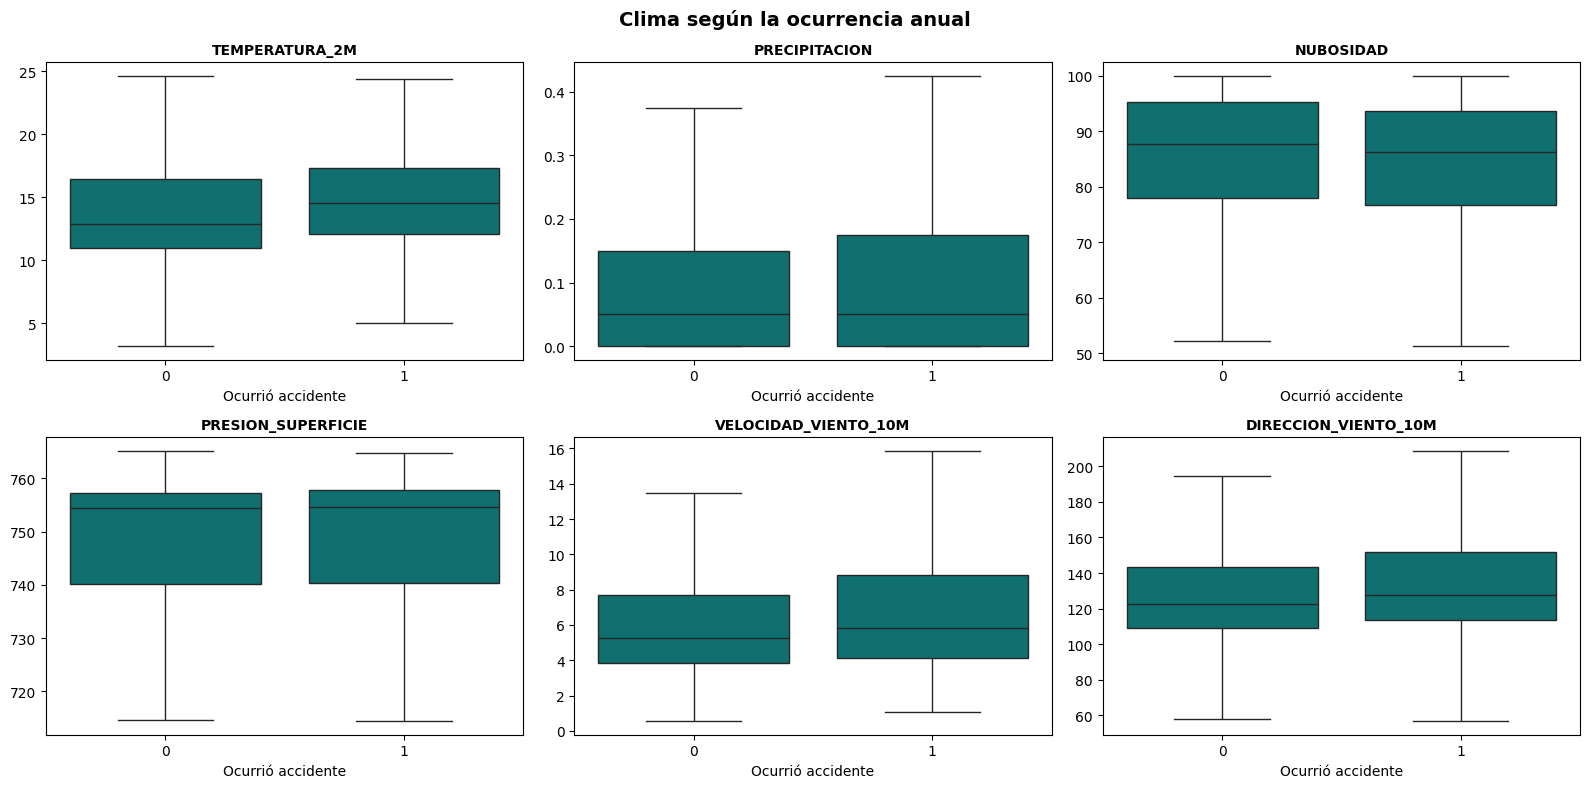

In [31]:
fig, ejes = plt.subplots(2, 3, figsize=(16, 8))
ejes = np.asarray(ejes).reshape(-1)

for eje, columna in zip(ejes, VARIABLES_CLIMA_SELECCIONADAS_CRUDAS):
    sns.boxplot(
        data=muestra_graficas,
        x=TARGET,
        y=columna,
        showfliers=False,
        color='teal',
        ax=eje
    )
    eje.set_title(columna, fontsize=10, weight='bold')
    eje.set_xlabel('Ocurrió accidente')
    eje.set_ylabel('')

plt.suptitle('Clima según la ocurrencia anual', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

## 3. Escenarios de modelado

Se comparan dos grupos de variables sobre las mismas filas y particiones temporales:

- **SIN_CLIMA:** zona, mes, día de la semana y hora.
- **CON_CLIMA:** las mismas variables más temperatura, precipitación, nubosidad, presión, velocidad del viento y la dirección transformada en seno y coseno.

La sensación térmica, la lluvia y la humedad se excluyen según el análisis de correlación del punto 2.7. `ANIO` se utiliza para los cortes temporales, pero no entra como predictor.

In [32]:
# Transformar la dirección del viento para respetar su naturaleza circular
angulo_viento = np.deg2rad(df['DIRECCION_VIENTO_10M'])
df['DIRECCION_VIENTO_10M_SIN'] = np.sin(angulo_viento)
df['DIRECCION_VIENTO_10M_COS'] = np.cos(angulo_viento)

VARIABLES_BASE = ['ZONA_CIUDAD', 'MES', 'DIA_SEMANA', 'HORA']
VARIABLES_CLIMA = [
    'TEMPERATURA_2M',
    'PRECIPITACION',
    'NUBOSIDAD',
    'PRESION_SUPERFICIE',
    'VELOCIDAD_VIENTO_10M',
    'DIRECCION_VIENTO_10M_SIN',
    'DIRECCION_VIENTO_10M_COS'
]

ESCENARIOS = {
    'SIN_CLIMA': VARIABLES_BASE,
    'CON_CLIMA': VARIABLES_BASE + VARIABLES_CLIMA,
}

pd.DataFrame([
    {'ESCENARIO': nombre, 'N_VARIABLES': len(cols), 'VARIABLES': ', '.join(cols)}
    for nombre, cols in ESCENARIOS.items()
])

,ESCENARIO,N_VARIABLES,VARIABLES
0,SIN_CLIMA,4,"ZONA_CIUDAD, MES, DIA_SEMANA, HORA"
1,CON_CLIMA,11,"ZONA_CIUDAD, MES, DIA_SEMANA, HORA, TEMPERATUR..."


## 4. Partición temporal de entrenamiento, validación y prueba

La evaluación conserva el orden cronológico para medir la capacidad de generalización hacia años posteriores:

- **Entrenamiento:** años hasta 2020.
- **Validación:** 2021–2023, utilizada para comparar modelos, escenarios y umbrales.
- **Prueba:** 2024–2025, aislada hasta terminar la selección.

`ANIO` define las particiones, pero no se incluye entre los predictores.

In [33]:
mascara_train = df['ANIO'] <= 2020
mascara_val = df['ANIO'].between(2021, 2023)
mascara_test = df['ANIO'] >= 2024

particiones = {
    'ENTRENAMIENTO': df.loc[mascara_train].copy(),
    'VALIDACION': df.loc[mascara_val].copy(),
    'PRUEBA': df.loc[mascara_test].copy(),
}

resumen_particiones = pd.DataFrame([
    {
        'PARTICION': nombre,
        'ANIOS': f'{datos.ANIO.min()}–{datos.ANIO.max()}',
        'FILAS': len(datos),
        'POSITIVOS': int(datos[TARGET].sum()),
        'PREVALENCIA': datos[TARGET].mean(),
    }
    for nombre, datos in particiones.items()
])
display(resumen_particiones)

,PARTICION,ANIOS,FILAS,POSITIVOS,PREVALENCIA
0,ENTRENAMIENTO,2007–2020,4233600,370657,0.0876
1,VALIDACION,2021–2023,907200,63460,0.0700
2,PRUEBA,2024–2025,604800,25151,0.0416


In [34]:
# Validar que los periodos sean completos y no se superpongan
for nombre, datos in particiones.items():
    assert len(datos) > 0, f'La partición {nombre} está vacía.'

anios_train = set(particiones['ENTRENAMIENTO']['ANIO'].unique())
anios_val = set(particiones['VALIDACION']['ANIO'].unique())
anios_test = set(particiones['PRUEBA']['ANIO'].unique())

assert anios_train.isdisjoint(anios_val)
assert anios_train.isdisjoint(anios_test)
assert anios_val.isdisjoint(anios_test)
assert len(anios_train | anios_val | anios_test) == df['ANIO'].nunique()

print('Particiones temporales independientes y reutilizables en ambos escenarios.')

Particiones temporales independientes y reutilizables en ambos escenarios.


### 4.1 Preparación de la muestra de entrenamiento

La cuadrícula anual contiene varios millones de combinaciones. Para que la búsqueda de hiperparámetros sea viable, se conservan todos los patrones positivos del entrenamiento y se toma una muestra reproducible de hasta 750.000 negativos.

Este muestreo se aplica únicamente durante el ajuste. Los conjuntos completos de validación y prueba no se modifican. Debido al cambio de prevalencia introducido por el muestreo, `predict_proba` se interpreta como un score de clasificación y no como una probabilidad poblacional calibrada.

In [35]:
MAX_NEGATIVOS_AJUSTE = 750_000

def construir_muestra_ajuste(datos, max_negativos=MAX_NEGATIVOS_AJUSTE):
    positivos = datos[datos[TARGET].eq(1)]
    negativos = datos[datos[TARGET].eq(0)]
    negativos_muestra = negativos.sample(
        n=min(max_negativos, len(negativos)),
        random_state=RANDOM_STATE
    )

    return (
        pd.concat([positivos, negativos_muestra], ignore_index=True)
        .sample(frac=1, random_state=RANDOM_STATE)
        .reset_index(drop=True)
    )

train_ajuste = construir_muestra_ajuste(
    particiones['ENTRENAMIENTO']
)

comparacion_muestra = pd.DataFrame({
    'ENTRENAMIENTO_COMPLETO': (
        particiones['ENTRENAMIENTO'][TARGET].value_counts()
    ),
    'MUESTRA_DE_AJUSTE': train_ajuste[TARGET].value_counts(),
}).fillna(0).astype(int)

display(comparacion_muestra)

,ENTRENAMIENTO_COMPLETO,MUESTRA_DE_AJUSTE
OCURRIO_ACCIDENTE,,
0,3862943,750000
1,370657,370657


## 5. Preprocesamiento

`ZONA_CIUDAD`, `MES`, `DIA_SEMANA` y `HORA` representan categorías, no magnitudes continuas. Se codifican con One-Hot Encoding. Las variables meteorológicas se imputan por mediana y se estandarizan.

In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

VARIABLES_CATEGORICAS = VARIABLES_BASE

def crear_preprocesador(columnas):
    categoricas = [c for c in VARIABLES_CATEGORICAS if c in columnas]
    numericas = [c for c in columnas if c not in categoricas]

    transformadores = []
    if categoricas:
        transformadores.append((
            'categoricas',
            OneHotEncoder(handle_unknown='ignore'),
            categoricas
        ))
    if numericas:
        transformadores.append((
            'numericas',
            Pipeline([
                ('imputacion', SimpleImputer(strategy='median')),
                ('escalado', StandardScaler()),
            ]),
            numericas
        ))

    return ColumnTransformer(transformers=transformadores, remainder='drop')

## 6. Métricas y selección de umbral

El umbral por defecto de 0,5 no se asume automáticamente como óptimo. Para cada candidato se selecciona un umbral usando **solo validación**, maximizando `Balanced Accuracy`.

Se reportan:

- ROC-AUC
- Average Precision
- F1
- Balanced Accuracy
- Precision
- Recall
- Log Loss
- Brier Score
- proporción de positivos predichos

In [37]:
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

def seleccionar_umbral_balanceado(y_real, y_prob):
    fpr, tpr, thresholds = roc_curve(y_real, y_prob)
    indice = np.argmax(tpr - fpr)  # equivalente a maximizar Balanced Accuracy
    umbral = thresholds[indice]

    if not np.isfinite(umbral):
        umbral = 0.5
    return float(np.clip(umbral, 0.0, 1.0))

def calcular_metricas(y_real, y_prob, umbral=0.5):
    y_pred = (np.asarray(y_prob) >= umbral).astype(int)
    return {
        'ROC_AUC': roc_auc_score(y_real, y_prob),
        'AVERAGE_PRECISION': average_precision_score(y_real, y_prob),
        'F1': f1_score(y_real, y_pred, zero_division=0),
        'BALANCED_ACCURACY': balanced_accuracy_score(y_real, y_pred),
        'PRECISION': precision_score(y_real, y_pred, zero_division=0),
        'RECALL': recall_score(y_real, y_pred, zero_division=0),
        'LOG_LOSS': log_loss(y_real, y_prob),
        'BRIER': brier_score_loss(y_real, y_prob),
        'TASA_POSITIVOS_PREDICHOS': y_pred.mean(),
        'UMBRAL': umbral,
    }

## 7. Línea base

La línea base no aprende patrones. Asigna a todas las observaciones la prevalencia positiva calculada únicamente con el conjunto de entrenamiento y utiliza la clase mayoritaria como clasificación.

Esta comparación permite determinar si los modelos aportan capacidad de discriminación frente a una referencia sin aprendizaje. Debido al desbalance hacia la clase negativa, las métricas se analizan de forma conjunta y no únicamente mediante la exactitud general.

In [38]:
y_train = particiones['ENTRENAMIENTO'][TARGET].to_numpy()
y_val = particiones['VALIDACION'][TARGET].to_numpy()

prevalencia_train = y_train.mean()
prob_base = np.full(len(y_val), prevalencia_train, dtype=float)
clase_mayoritaria = int(prevalencia_train >= 0.5)
pred_base = np.full(len(y_val), clase_mayoritaria, dtype=int)

metricas_base = {
    'ROC_AUC': 0.5,
    'AVERAGE_PRECISION': y_val.mean(),
    'F1': f1_score(y_val, pred_base, zero_division=0),
    'BALANCED_ACCURACY': balanced_accuracy_score(y_val, pred_base),
    'PRECISION': precision_score(y_val, pred_base, zero_division=0),
    'RECALL': recall_score(y_val, pred_base, zero_division=0),
    'LOG_LOSS': log_loss(y_val, prob_base),
    'BRIER': brier_score_loss(y_val, prob_base),
    'TASA_POSITIVOS_PREDICHOS': pred_base.mean(),
    'UMBRAL': 0.5,
}

display(pd.Series(metricas_base, name='LINEA_BASE').to_frame())

,LINEA_BASE
ROC_AUC,0.5000
AVERAGE_PRECISION,0.0700
F1,0.0000
BALANCED_ACCURACY,0.5000
PRECISION,0.0000
RECALL,0.0000
LOG_LOSS,0.2556
BRIER,0.0654
TASA_POSITIVOS_PREDICHOS,0.0000
UMBRAL,0.5000


## 8. Evaluación de modelos

Se evalúan cuatro familias de clasificación bajo los escenarios `SIN_CLIMA` y `CON_CLIMA`. 

La búsqueda utiliza validación cruzada estratificada exclusivamente dentro del conjunto de entrenamiento. Después, el mejor estimador de cada escenario se evalúa sobre el conjunto de validación y su umbral se selecciona maximizando la exactitud balanceada.

In [39]:
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import ParameterGrid, StratifiedKFold, cross_val_score
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

resultados_validacion = []
modelos_validacion = {}
umbrales_validacion = {}
mejores_parametros = {}

CONFIGURACIONES_ESPERADAS = [
    (modelo, escenario)
    for modelo in ['Regresión logística', 'Random Forest', 'XGBoost', 'MLP']
    for escenario in ESCENARIOS
]


### Función auxiliar de evaluación

La función aplica exactamente el mismo procedimiento a un solo algoritmo en los dos escenarios. Además de devolver sus métricas, conserva el estimador, el umbral y los mejores parámetros para las secciones posteriores.

In [40]:
def evaluar_modelo(nombre, modelo_base, parametros):
    resultados_modelo = []
    train = train_ajuste
    val = particiones['VALIDACION']

    for escenario, columnas in ESCENARIOS.items():
        configuraciones = list(ParameterGrid(parametros))
        total = len(configuraciones)
        resultados_cv = []

        print(f'\n===== {nombre} | {escenario} =====', flush=True)
        print(f'Configuraciones por evaluar: {total}', flush=True)

        for numero, configuracion in enumerate(configuraciones, start=1):
            parametros_legibles = {
                clave.replace('modelo__', ''): valor
                for clave, valor in configuracion.items()
            }
            print(
                f'[{numero}/{total}] {parametros_legibles}',
                flush=True
            )

            pipeline = Pipeline([
                ('preprocesamiento', crear_preprocesador(columnas)),
                ('modelo', clone(modelo_base)),
            ]).set_params(**configuracion)

            inicio_configuracion = time.time()
            scores = cross_val_score(
                pipeline,
                train[columnas],
                train[TARGET],
                scoring='roc_auc',
                cv=cv,
                n_jobs=2,
                pre_dispatch=2,
            )
            minutos = (time.time() - inicio_configuracion) / 60
            roc_auc_cv = scores.mean()

            resultados_cv.append({
                'PARAMETROS_PIPELINE': configuracion,
                'ROC_AUC_CV': roc_auc_cv,
                'DESVIACION_CV': scores.std(),
                'TIEMPO_CV_MIN': minutos,
            })
            print(
                f'    completada en {minutos:.2f} min | '
                f'ROC-AUC CV={roc_auc_cv:.4f}',
                flush=True
            )

        tabla_cv = pd.DataFrame(resultados_cv).sort_values(
            ['ROC_AUC_CV', 'DESVIACION_CV'],
            ascending=[False, True]
        ).reset_index(drop=True)
        mejor_configuracion = tabla_cv.iloc[0]['PARAMETROS_PIPELINE']

        print(
            f'Mejor configuración {escenario}: '
            f'{ {k.replace("modelo__", ""): v for k, v in mejor_configuracion.items()} }',
            flush=True
        )

        mejor_modelo = Pipeline([
            ('preprocesamiento', crear_preprocesador(columnas)),
            ('modelo', clone(modelo_base)),
        ]).set_params(**mejor_configuracion)

        inicio_ajuste = time.time()
        mejor_modelo.fit(train[columnas], train[TARGET])
        duracion_ajuste = (time.time() - inicio_ajuste) / 60

        prob_val = mejor_modelo.predict_proba(val[columnas])[:, 1]
        umbral = seleccionar_umbral_balanceado(val[TARGET], prob_val)
        metricas = calcular_metricas(val[TARGET], prob_val, umbral)

        fila = {
            'MODELO': nombre,
            'ESCENARIO': escenario,
            'TIEMPO_MIN': tabla_cv['TIEMPO_CV_MIN'].sum() + duracion_ajuste,
            **metricas,
        }
        resultados_modelo.append(fila)
        resultados_validacion.append(fila)
        modelos_validacion[(nombre, escenario)] = mejor_modelo
        umbrales_validacion[(nombre, escenario)] = umbral
        mejores_parametros[(nombre, escenario)] = mejor_configuracion

        print(
            f'Validación terminada | Balanced Accuracy='
            f'{metricas["BALANCED_ACCURACY"]:.4f} | '
            f'ROC-AUC={metricas["ROC_AUC"]:.4f}',
            flush=True
        )

    return pd.DataFrame(resultados_modelo)

### 8.1 Regresión logística

Se evalúa una regresión logística con regularización Elastic Net. La búsqueda compara distintos valores de `C` y `l1_ratio`, utilizando el solver `saga`. En total se prueban 6 configuraciones por escenario.

In [45]:
logistica_base = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    max_iter=1000,
    random_state=RANDOM_STATE
)

parametros_logistica = {
    'modelo__C': [0.001, 0.01, 0.1],
    'modelo__l1_ratio': [0.5, 1.0],
    'modelo__solver': ['saga'],
}

logistica_base

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'elasticnet'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'saga'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elast

In [46]:
resultados_logistica = evaluar_modelo(
    'Regresión logística',
    logistica_base,
    parametros_logistica
)
display(resultados_logistica.round(4))


===== Regresión logística | SIN_CLIMA =====
Configuraciones por evaluar: 6
[1/6] {'C': 0.001, 'l1_ratio': 0.5, 'solver': 'saga'}
    completada en 0.51 min | ROC-AUC CV=0.6660
[2/6] {'C': 0.001, 'l1_ratio': 1.0, 'solver': 'saga'}
    completada en 0.23 min | ROC-AUC CV=0.6500
[3/6] {'C': 0.01, 'l1_ratio': 0.5, 'solver': 'saga'}
    completada en 0.80 min | ROC-AUC CV=0.6903
[4/6] {'C': 0.01, 'l1_ratio': 1.0, 'solver': 'saga'}
    completada en 0.43 min | ROC-AUC CV=0.6896
[5/6] {'C': 0.1, 'l1_ratio': 0.5, 'solver': 'saga'}
    completada en 1.20 min | ROC-AUC CV=0.6906
[6/6] {'C': 0.1, 'l1_ratio': 1.0, 'solver': 'saga'}
    completada en 0.60 min | ROC-AUC CV=0.6906
Mejor configuración SIN_CLIMA: {'C': 0.1, 'l1_ratio': 1.0, 'solver': 'saga'}
Validación terminada | Balanced Accuracy=0.6120 | ROC-AUC=0.6521

===== Regresión logística | CON_CLIMA =====
Configuraciones por evaluar: 6
[1/6] {'C': 0.001, 'l1_ratio': 0.5, 'solver': 'saga'}
    completada en 0.45 min | ROC-AUC CV=0.6607
[2/6]

,MODELO,ESCENARIO,TIEMPO_MIN,ROC_AUC,AVERAGE_PRECISION,F1,BALANCED_ACCURACY,PRECISION,RECALL,LOG_LOSS,BRIER,TASA_POSITIVOS_PREDICHOS,UMBRAL
0,Regresión logística,SIN_CLIMA,4.2586,0.6521,0.1113,0.1745,0.6120,0.0997,0.6978,0.4288,0.1328,0.4894,0.3333
1,Regresión logística,CON_CLIMA,6.2023,0.6542,0.1124,0.1754,0.6135,0.1004,0.6966,0.4362,0.1363,0.4856,0.3409


In [47]:
for escenario in ESCENARIOS:
    clave = ('Regresión logística', escenario)
    print(f'{escenario}: {mejores_parametros[clave]}')

SIN_CLIMA: {'modelo__C': 0.1, 'modelo__l1_ratio': 1.0, 'modelo__solver': 'saga'}
CON_CLIMA: {'modelo__C': 0.1, 'modelo__l1_ratio': 1.0, 'modelo__solver': 'saga'}


### 8.2 Random Forest

Se evalúa un modelo Random Forest variando el número de árboles y el tamaño mínimo requerido para dividir un nodo. La profundidad máxima se mantiene en 10. En total se prueban 4 configuraciones por escenario.

In [48]:
random_forest_base = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=1
)

parametros_random_forest = {
    'modelo__n_estimators': [100, 150],
    'modelo__max_depth': [10],
    'modelo__min_samples_split': [2, 5],
}

random_forest_base

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total 

In [49]:
resultados_random_forest = evaluar_modelo(
    'Random Forest',
    random_forest_base,
    parametros_random_forest
)
display(resultados_random_forest.round(4))


===== Random Forest | SIN_CLIMA =====
Configuraciones por evaluar: 4
[1/4] {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
    completada en 1.09 min | ROC-AUC CV=0.6727
[2/4] {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 150}
    completada en 1.38 min | ROC-AUC CV=0.6726
[3/4] {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
    completada en 0.93 min | ROC-AUC CV=0.6726
[4/4] {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 150}
    completada en 1.48 min | ROC-AUC CV=0.6727
Mejor configuración SIN_CLIMA: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Validación terminada | Balanced Accuracy=0.6115 | ROC-AUC=0.6415

===== Random Forest | CON_CLIMA =====
Configuraciones por evaluar: 4
[1/4] {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
    completada en 2.21 min | ROC-AUC CV=0.6597
[2/4] {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 150}
    completada en 3.28 min | ROC-AUC CV=0.6597
[3/4]

,MODELO,ESCENARIO,TIEMPO_MIN,ROC_AUC,AVERAGE_PRECISION,F1,BALANCED_ACCURACY,PRECISION,RECALL,LOG_LOSS,BRIER,TASA_POSITIVOS_PREDICHOS,UMBRAL
0,Random Forest,SIN_CLIMA,5.6820,0.6415,0.1044,0.1720,0.6115,0.0974,0.7367,0.4376,0.1287,0.5293,0.3460
1,Random Forest,CON_CLIMA,13.5060,0.6293,0.0991,0.1640,0.6014,0.0913,0.8064,0.4377,0.1300,0.6178,0.3059


In [50]:
for escenario in ESCENARIOS:
    clave = ('Random Forest', escenario)
    print(f'{escenario}: {mejores_parametros[clave]}')

SIN_CLIMA: {'modelo__max_depth': 10, 'modelo__min_samples_split': 2, 'modelo__n_estimators': 100}
CON_CLIMA: {'modelo__max_depth': 10, 'modelo__min_samples_split': 2, 'modelo__n_estimators': 150}


### 8.3 XGBoost

Se evalúa XGBoost variando el número de árboles, la profundidad máxima y la tasa de aprendizaje. Después de la búsqueda inicial, se realiza una búsqueda refinada con un mayor número de árboles sobre las configuraciones que presentaron mejor desempeño. Las dos búsquedas se conservan como candidatos independientes para la comparación final.

In [51]:
xgboost_base = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    device='cuda',
    n_jobs=1,
    random_state=RANDOM_STATE,
)

parametros_xgboost = {
    'modelo__n_estimators': [50, 100, 150],
    'modelo__max_depth': [3, 6, 10],
    'modelo__learning_rate': [0.01, 0.1, 0.2],
}

xgboost_base

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [52]:
resultados_xgboost = evaluar_modelo(
    'XGBoost',
    xgboost_base,
    parametros_xgboost
)
display(resultados_xgboost.round(4))


===== XGBoost | SIN_CLIMA =====
Configuraciones por evaluar: 27
[1/27] {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50}
    completada en 0.07 min | ROC-AUC CV=0.5859
[2/27] {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}
    completada en 0.11 min | ROC-AUC CV=0.6181
[3/27] {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 150}
    completada en 0.15 min | ROC-AUC CV=0.6182
[4/27] {'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 50}
    completada en 0.09 min | ROC-AUC CV=0.6184
[5/27] {'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 100}
    completada en 0.17 min | ROC-AUC CV=0.6347
[6/27] {'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 150}
    completada en 0.22 min | ROC-AUC CV=0.6450
[7/27] {'learning_rate': 0.01, 'max_depth': 10, 'n_estimators': 50}
    completada en 0.17 min | ROC-AUC CV=0.6441
[8/27] {'learning_rate': 0.01, 'max_depth': 10, 'n_estimators': 100}
    completada en 0.27 min | ROC-AUC CV=0.6526
[9/27] {'learnin

,MODELO,ESCENARIO,TIEMPO_MIN,ROC_AUC,AVERAGE_PRECISION,F1,BALANCED_ACCURACY,PRECISION,RECALL,LOG_LOSS,BRIER,TASA_POSITIVOS_PREDICHOS,UMBRAL
0,XGBoost,SIN_CLIMA,4.6495,0.6558,0.1106,0.1744,0.6164,0.0988,0.7415,0.4272,0.1330,0.5249,0.3083
1,XGBoost,CON_CLIMA,8.7698,0.6591,0.1134,0.1749,0.6173,0.0991,0.7412,0.4301,0.1333,0.5231,0.3158


In [53]:
for escenario in ESCENARIOS:
    clave = ('XGBoost', escenario)
    print(f'{escenario}: {mejores_parametros[clave]}')

SIN_CLIMA: {'modelo__learning_rate': 0.2, 'modelo__max_depth': 10, 'modelo__n_estimators': 150}
CON_CLIMA: {'modelo__learning_rate': 0.2, 'modelo__max_depth': 6, 'modelo__n_estimators': 150}


In [56]:
# Nueva búsqueda de XGBoost sin eliminar los resultados originales

parametros_xgboost_refinados = {
    'modelo__n_estimators': [150, 250, 350],
    'modelo__max_depth': [6, 10],
    'modelo__learning_rate': [0.1, 0.2],
}

# Si se repite esta celda, retirar solamente una ejecución refinada anterior
resultados_validacion = [
    fila for fila in resultados_validacion
    if fila['MODELO'] != 'XGBoost refinado'
]

for almacenamiento in [
    modelos_validacion,
    umbrales_validacion,
    mejores_parametros
]:
    for clave in list(almacenamiento):
        if clave[0] == 'XGBoost refinado':
            del almacenamiento[clave]

# Ejecutar como candidato independiente
resultados_xgboost_refinados = evaluar_modelo(
    'XGBoost refinado',
    xgboost_base,
    parametros_xgboost_refinados
)


===== XGBoost refinado | SIN_CLIMA =====
Configuraciones por evaluar: 12
[1/12] {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 150}
    completada en 0.32 min | ROC-AUC CV=0.6923
[2/12] {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 250}
    completada en 0.36 min | ROC-AUC CV=0.6955
[3/12] {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 350}
    completada en 0.53 min | ROC-AUC CV=0.6969
[4/12] {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 150}
    completada en 0.34 min | ROC-AUC CV=0.6954
[5/12] {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 250}
    completada en 0.61 min | ROC-AUC CV=0.6966
[6/12] {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 350}
    completada en 0.89 min | ROC-AUC CV=0.6965
[7/12] {'learning_rate': 0.2, 'max_depth': 6, 'n_estimators': 150}
    completada en 0.27 min | ROC-AUC CV=0.6962
[8/12] {'learning_rate': 0.2, 'max_depth': 6, 'n_estimators': 250}
    completada en 0.38 min | ROC-AUC CV=0.6978
[9/12] {'le

In [57]:
# Añadirlo a las configuraciones esperadas para la consolidación
for escenario in ESCENARIOS:
    clave = ('XGBoost refinado', escenario)

    if clave not in CONFIGURACIONES_ESPERADAS:
        CONFIGURACIONES_ESPERADAS.append(clave)

# Comparar búsqueda original y refinada
comparacion_busquedas_xgboost = pd.concat([
    resultados_xgboost.assign(BUSQUEDA='ORIGINAL'),
    resultados_xgboost_refinados.assign(BUSQUEDA='REFINADA'),
], ignore_index=True)

display(
    comparacion_busquedas_xgboost[
        [
            'BUSQUEDA',
            'MODELO',
            'ESCENARIO',
            'BALANCED_ACCURACY',
            'ROC_AUC',
            'AVERAGE_PRECISION',
            'F1',
            'LOG_LOSS',
            'UMBRAL',
            'TIEMPO_MIN',
        ]
    ].sort_values(
        ['BALANCED_ACCURACY', 'ROC_AUC', 'LOG_LOSS'],
        ascending=[False, False, True]
    ).round(4)
)

,BUSQUEDA,MODELO,ESCENARIO,BALANCED_ACCURACY,ROC_AUC,AVERAGE_PRECISION,F1,LOG_LOSS,UMBRAL,TIEMPO_MIN
3,REFINADA,XGBoost refinado,CON_CLIMA,0.6201,0.6632,0.1153,0.1768,0.4310,0.3178,7.4376
1,ORIGINAL,XGBoost,CON_CLIMA,0.6173,0.6591,0.1134,0.1749,0.4301,0.3158,8.7698
2,REFINADA,XGBoost refinado,SIN_CLIMA,0.6166,0.6569,0.1115,0.1756,0.4268,0.3186,5.8323
0,ORIGINAL,XGBoost,SIN_CLIMA,0.6164,0.6558,0.1106,0.1744,0.4272,0.3083,4.6495


### 8.4 Red neuronal MLP

Se evalúa una red neuronal MLP con una y dos capas ocultas, dos valores de regularización y una tasa de aprendizaje de `0.001`. Se utiliza detención temprana para interrumpir el entrenamiento cuando el desempeño deja de mejorar. En total se prueban 4 configuraciones por escenario.

In [60]:
mlp_base = MLPClassifier(
    max_iter=100,
    early_stopping=True,
    n_iter_no_change=5,
    random_state=RANDOM_STATE,
)

parametros_mlp = {
    'modelo__hidden_layer_sizes': [(64,), (64, 32)],
    'modelo__alpha': [0.0001, 0.001],
    'modelo__learning_rate_init': [0.001],
}

mlp_base

,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",100
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"early_stopping early_stopping: bool, default=FalseWhether to use early stopping to terminate training when validationscore is not improving. If set to True, it will automatically setaside ``validation_fraction`` of training data as validation andterminate training when validation score is not improving by at least``tol`` for ``n_iter_no_change`` consecutive epochs. The split isstratified, except in a multilabel setting.If early stopping is False, then the training stops when the trainingloss does not improve by more than ``tol`` for ``n_iter_no_change``consecutive passes over the training set.Only effective when solver='sgd' or 'adam'.",True
,"n_iter_no_change n_iter_no_change: int, default=10Maximum number of epochs to not meet ``tol`` improvement.Only effective when solver='sgd' or 'adam'... versionadded:: 0.20",5
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.

In [61]:
resultados_mlp = evaluar_modelo(
    'MLP',
    mlp_base,
    parametros_mlp
)
display(resultados_mlp.round(4))


===== MLP | SIN_CLIMA =====
Configuraciones por evaluar: 4
[1/4] {'alpha': 0.0001, 'hidden_layer_sizes': (64,), 'learning_rate_init': 0.001}
    completada en 1.41 min | ROC-AUC CV=0.7003
[2/4] {'alpha': 0.0001, 'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.001}
    completada en 1.69 min | ROC-AUC CV=0.6999
[3/4] {'alpha': 0.001, 'hidden_layer_sizes': (64,), 'learning_rate_init': 0.001}
    completada en 1.03 min | ROC-AUC CV=0.7007
[4/4] {'alpha': 0.001, 'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.001}
    completada en 2.24 min | ROC-AUC CV=0.7008
Mejor configuración SIN_CLIMA: {'alpha': 0.001, 'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.001}
Validación terminada | Balanced Accuracy=0.6202 | ROC-AUC=0.6568

===== MLP | CON_CLIMA =====
Configuraciones por evaluar: 4
[1/4] {'alpha': 0.0001, 'hidden_layer_sizes': (64,), 'learning_rate_init': 0.001}
    completada en 1.23 min | ROC-AUC CV=0.7013
[2/4] {'alpha': 0.0001, 'hidden_layer_sizes': (64, 32), '

,MODELO,ESCENARIO,TIEMPO_MIN,ROC_AUC,AVERAGE_PRECISION,F1,BALANCED_ACCURACY,PRECISION,RECALL,LOG_LOSS,BRIER,TASA_POSITIVOS_PREDICHOS,UMBRAL
0,MLP,SIN_CLIMA,9.4932,0.6568,0.1091,0.1751,0.6202,0.0989,0.7637,0.4303,0.1350,0.5402,0.2935
1,MLP,CON_CLIMA,13.3745,0.6661,0.1163,0.1781,0.6234,0.1011,0.7449,0.4234,0.1315,0.5153,0.3090


In [62]:
for escenario in ESCENARIOS:
    clave = ('MLP', escenario)
    print(f'{escenario}: {mejores_parametros[clave]}')

SIN_CLIMA: {'modelo__alpha': 0.001, 'modelo__hidden_layer_sizes': (64, 32), 'modelo__learning_rate_init': 0.001}
CON_CLIMA: {'modelo__alpha': 0.001, 'modelo__hidden_layer_sizes': (64, 32), 'modelo__learning_rate_init': 0.001}


### 8.5 Consolidación de resultados

Se consolidan las métricas obtenidas por la regresión logística, Random Forest, XGBoost, XGBoost refinado y la red neuronal MLP en los escenarios `SIN_CLIMA` y `CON_CLIMA`. Si una configuración fue ejecutada más de una vez, se conserva su resultado más reciente.

La tabla se ordena primero por `Balanced Accuracy`, luego por `ROC-AUC` y finalmente por menor `Log Loss`.

In [64]:
metricas_validacion = (
    pd.DataFrame(resultados_validacion)
    .drop_duplicates(subset=['MODELO', 'ESCENARIO'], keep='last')
)

metricas_validacion = metricas_validacion.sort_values(
    ['BALANCED_ACCURACY', 'ROC_AUC', 'LOG_LOSS'],
    ascending=[False, False, True]
).reset_index(drop=True)

display(metricas_validacion.round(4))

,MODELO,ESCENARIO,TIEMPO_MIN,ROC_AUC,AVERAGE_PRECISION,F1,BALANCED_ACCURACY,PRECISION,RECALL,LOG_LOSS,BRIER,TASA_POSITIVOS_PREDICHOS,UMBRAL
0,MLP,CON_CLIMA,13.3745,0.6661,0.1163,0.1781,0.6234,0.1011,0.7449,0.4234,0.1315,0.5153,0.3090
1,MLP,SIN_CLIMA,9.4932,0.6568,0.1091,0.1751,0.6202,0.0989,0.7637,0.4303,0.1350,0.5402,0.2935
2,XGBoost refinado,CON_CLIMA,7.4376,0.6632,0.1153,0.1768,0.6201,0.1004,0.7356,0.4310,0.1346,0.5123,0.3178
3,XGBoost,CON_CLIMA,8.7698,0.6591,0.1134,0.1749,0.6173,0.0991,0.7412,0.4301,0.1333,0.5231,0.3158
4,XGBoost refinado,SIN_CLIMA,5.8323,0.6569,0.1115,0.1756,0.6166,0.1000,0.7222,0.4268,0.1328,0.5054,0.3186
5,XGBoost,SIN_CLIMA,4.6495,0.6558,0.1106,0.1744,0.6164,0.0988,0.7415,0.4272,0.1330,0.5249,0.3083
6,Regresión logística,CON_CLIMA,6.2023,0.6542,0.1124,0.1754,0.6135,0.1004,0.6966,0.4362,0.1363,0.4856,0.3409
7,Regresión logística,SIN_CLIMA,4.2586,0.6521,0.1113,0.1745,0.6120,0.0997,0.6978,0.4288,0.1328,0.4894,0.3333
8,Random Forest,SIN_CLIMA,5.6820,0.6415,0.1044,0.1720,0.6115,0.0974,0.7367,0.4376,0.1287,0.5293,0.3460
9,Random Forest,CON_CLIMA,13.5060,0.6293,0.0991,0.1640,0.6014,0.0913,0.8064,0.4377,0.1300,0.6178,0.3059


## 9. Comparación contra la línea base

Se añade la línea base a la tabla para evitar interpretar de forma aislada un F1 elevado.

In [65]:
fila_base = {
    'MODELO': 'Línea base',
    'ESCENARIO': 'SIN_MODELO',
    'TIEMPO_MIN': 0.0,
    **metricas_base,
}

comparacion_validacion = pd.concat([
    pd.DataFrame([fila_base]),
    metricas_validacion,
], ignore_index=True)

display(comparacion_validacion.round(4))

,MODELO,ESCENARIO,TIEMPO_MIN,ROC_AUC,AVERAGE_PRECISION,F1,BALANCED_ACCURACY,PRECISION,RECALL,LOG_LOSS,BRIER,TASA_POSITIVOS_PREDICHOS,UMBRAL
0,Línea base,SIN_MODELO,0.0000,0.5000,0.0700,0.0000,0.5000,0.0000,0.0000,0.2556,0.0654,0.0000,0.5000
1,MLP,CON_CLIMA,13.3745,0.6661,0.1163,0.1781,0.6234,0.1011,0.7449,0.4234,0.1315,0.5153,0.3090
2,MLP,SIN_CLIMA,9.4932,0.6568,0.1091,0.1751,0.6202,0.0989,0.7637,0.4303,0.1350,0.5402,0.2935
3,XGBoost refinado,CON_CLIMA,7.4376,0.6632,0.1153,0.1768,0.6201,0.1004,0.7356,0.4310,0.1346,0.5123,0.3178
4,XGBoost,CON_CLIMA,8.7698,0.6591,0.1134,0.1749,0.6173,0.0991,0.7412,0.4301,0.1333,0.5231,0.3158
5,XGBoost refinado,SIN_CLIMA,5.8323,0.6569,0.1115,0.1756,0.6166,0.1000,0.7222,0.4268,0.1328,0.5054,0.3186
6,XGBoost,SIN_CLIMA,4.6495,0.6558,0.1106,0.1744,0.6164,0.0988,0.7415,0.4272,0.1330,0.5249,0.3083
7,Regresión logística,CON_CLIMA,6.2023,0.6542,0.1124,0.1754,0.6135,0.1004,0.6966,0.4362,0.1363,0.4856,0.3409
8,Regresión logística,SIN_CLIMA,4.2586,0.6521,0.1113,0.1745,0.6120,0.0997,0.6978,0.4288,0.1328,0.4894,0.3333
9,Random Forest,SIN_CLIMA,5.6820,0.6415,0.1044,0.1720,0.6115,0.0974,0.7367,0.4376,0.1287,0.5293,0.3460


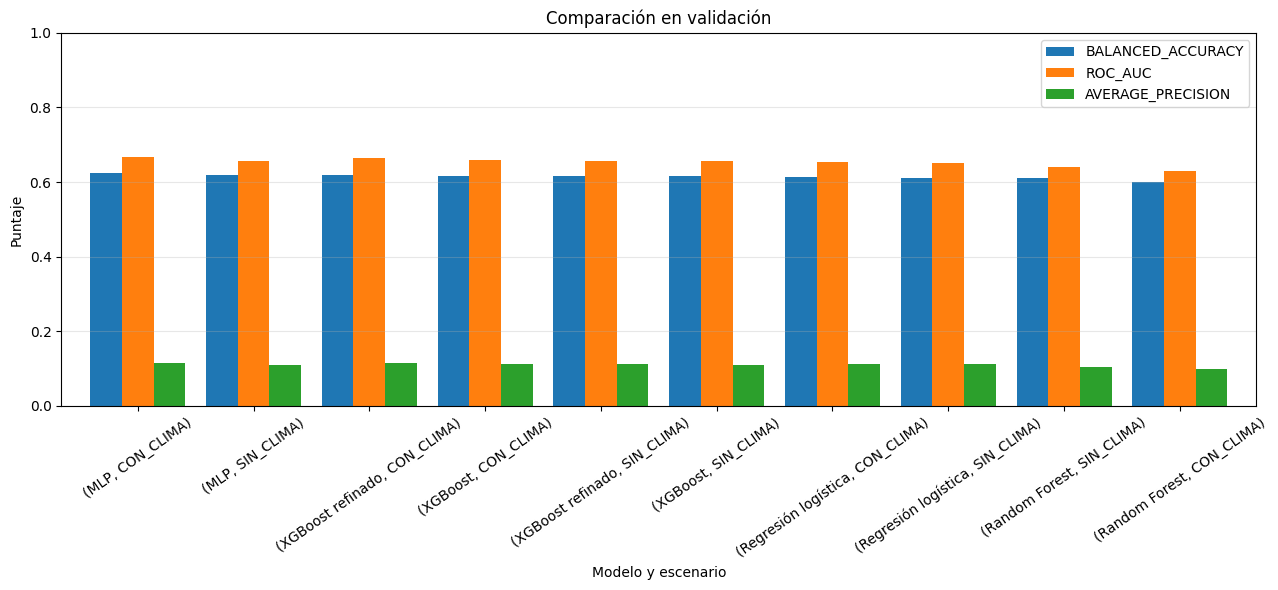

In [66]:
metricas_grafica = ['BALANCED_ACCURACY', 'ROC_AUC', 'AVERAGE_PRECISION']

grafica = (
    metricas_validacion
    .set_index(['MODELO', 'ESCENARIO'])[metricas_grafica]
)
ax = grafica.plot(kind='bar', figsize=(13, 6), ylim=(0, 1), width=0.82)
ax.set_title('Comparación en validación')
ax.set_xlabel('Modelo y escenario')
ax.set_ylabel('Puntaje')
ax.tick_params(axis='x', rotation=35)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Selección del ganador

El ganador se selecciona por:

1. mayor `Balanced Accuracy`;
2. mayor `ROC-AUC` como desempate;
3. menor `Log Loss` como segundo desempate.

El test todavía no se ha utilizado.

In [67]:
ganador = metricas_validacion.iloc[0]
NOMBRE_GANADOR = ganador['MODELO']
ESCENARIO_GANADOR = ganador['ESCENARIO']
COLUMNAS_GANADORAS = ESCENARIOS[ESCENARIO_GANADOR]
UMBRAL_GANADOR = float(ganador['UMBRAL'])

print(f'Modelo seleccionado   : {NOMBRE_GANADOR}')
print(f'Escenario seleccionado: {ESCENARIO_GANADOR}')
print(f'Umbral validación     : {UMBRAL_GANADOR:.4f}')
display(ganador.to_frame('VALIDACION'))

Modelo seleccionado   : MLP
Escenario seleccionado: CON_CLIMA
Umbral validación     : 0.3090


,VALIDACION
MODELO,MLP
ESCENARIO,CON_CLIMA
TIEMPO_MIN,13.3745
ROC_AUC,0.6661
AVERAGE_PRECISION,0.1163
F1,0.1781
BALANCED_ACCURACY,0.6234
PRECISION,0.1011
RECALL,0.7449
LOG_LOSS,0.4234


## 11. Evaluación final en prueba

El modelo seleccionado se evalúa una única vez sobre el periodo temporal 2024–2025, que permaneció aislado durante la selección. Para clasificar las observaciones se conserva el umbral obtenido con la validación de 2021–2023.

In [68]:
modelo_seleccionado = modelos_validacion[(NOMBRE_GANADOR, ESCENARIO_GANADOR)]
prueba = particiones['PRUEBA']

prob_test = modelo_seleccionado.predict_proba(prueba[COLUMNAS_GANADORAS])[:, 1]
metricas_test = calcular_metricas(
    prueba[TARGET],
    prob_test,
    UMBRAL_GANADOR
)

resultado_test = pd.Series(metricas_test, name='PRUEBA_FINAL').to_frame()
display(resultado_test.round(4))

,PRUEBA_FINAL
ROC_AUC,0.6308
AVERAGE_PRECISION,0.0603
F1,0.1055
BALANCED_ACCURACY,0.5981
PRECISION,0.0571
RECALL,0.6920
LOG_LOSS,0.4047
BRIER,0.1230
TASA_POSITIVOS_PREDICHOS,0.5040
UMBRAL,0.3090


## 11.1 Matriz de confusión


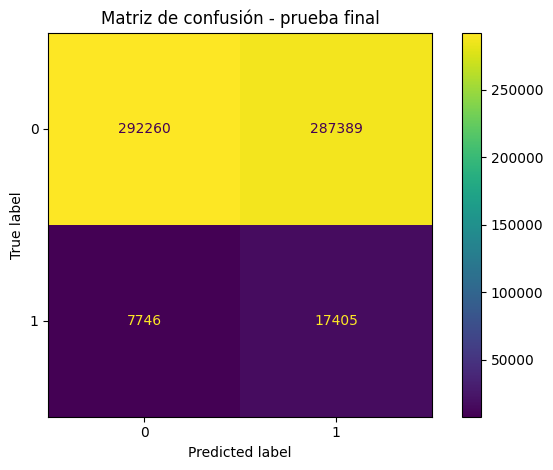

In [69]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

pred_test = (prob_test >= UMBRAL_GANADOR).astype(int)
cm = confusion_matrix(prueba[TARGET], pred_test)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1]).plot()
plt.title('Matriz de confusión - prueba final')
plt.tight_layout()
plt.show()

## 11.2 Curvas ROC y Precision-Recall


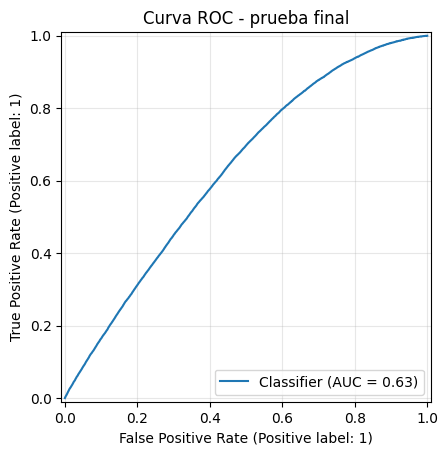

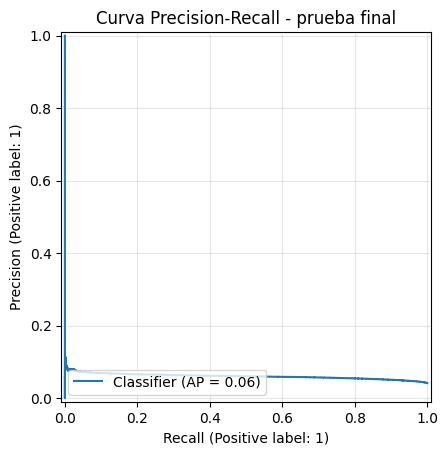

In [70]:
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

RocCurveDisplay.from_predictions(prueba[TARGET], prob_test)
plt.title('Curva ROC - prueba final')
plt.grid(alpha=0.3)
plt.show()

PrecisionRecallDisplay.from_predictions(prueba[TARGET], prob_test)
plt.title('Curva Precision-Recall - prueba final')
plt.grid(alpha=0.3)
plt.show()

## 12. Comparación final: sin clima vs. con clima

La comparación de escenarios debe realizarse sobre las mismas observaciones. Esta tabla permite determinar si el clima aporta señal adicional frente a las variables espaciales y temporales.

In [71]:
comparacion_escenarios = (
    metricas_validacion
    .groupby('ESCENARIO', as_index=False)
    .first()
    [['ESCENARIO', 'MODELO', 'BALANCED_ACCURACY', 'ROC_AUC', 'AVERAGE_PRECISION', 'F1', 'LOG_LOSS']]
)
display(comparacion_escenarios.round(4))

,ESCENARIO,MODELO,BALANCED_ACCURACY,ROC_AUC,AVERAGE_PRECISION,F1,LOG_LOSS
0,CON_CLIMA,MLP,0.6234,0.6661,0.1163,0.1781,0.4234
1,SIN_CLIMA,MLP,0.6202,0.6568,0.1091,0.1751,0.4303


## 13. Reajuste para producción

Después de obtener la evaluación final, se reajusta el pipeline ganador con **entrenamiento + validación** para realizar la exportación del modelo

In [72]:
from sklearn.base import clone

desarrollo = pd.concat([
    particiones['ENTRENAMIENTO'],
    particiones['VALIDACION'],
], ignore_index=True)

desarrollo_ajuste = construir_muestra_ajuste(desarrollo)

modelo_final = clone(modelo_seleccionado)
modelo_final.fit(
    desarrollo_ajuste[COLUMNAS_GANADORAS],
    desarrollo_ajuste[TARGET]
)

print('Modelo final reajustado con una muestra de entrenamiento + validación hasta 2023.')

Modelo final reajustado con una muestra de entrenamiento + validación hasta 2023.


## 14. Función de inferencia

La función recibe la zona, la fecha, la hora y, cuando corresponde, las condiciones meteorológicas. A partir de la fecha se calculan `MES` y `DIA_SEMANA`, mientras que `ANIO` no se incorpora como predictor.

La función devuelve el score del modelo, la clasificación obtenida con el umbral seleccionado y el umbral utilizado. Si el modelo corresponde al escenario `CON_CLIMA`, la consulta debe incluir las variables meteorológicas requeridas.

In [73]:
def predecir_patron_ocurrencia(
    modelo,
    zona_ciudad,
    fecha,
    hora,
    umbral,
    escenario,
    temperatura_2m=None,
    precipitacion=None,
    nubosidad=None,
    presion_superficie=None,
    velocidad_viento_10m=None,
    direccion_viento_10m=None,
):
    fecha = pd.Timestamp(fecha)

    fila = {
        'ZONA_CIUDAD': int(zona_ciudad),
        'MES': int(fecha.month),
        'DIA_SEMANA': int(fecha.dayofweek),
        'HORA': int(hora),
    }

    if escenario == 'CON_CLIMA':
        clima_crudo = {
            'TEMPERATURA_2M': temperatura_2m,
            'PRECIPITACION': precipitacion,
            'NUBOSIDAD': nubosidad,
            'PRESION_SUPERFICIE': presion_superficie,
            'VELOCIDAD_VIENTO_10M': velocidad_viento_10m,
            'DIRECCION_VIENTO_10M': direccion_viento_10m,
        }
        faltantes = [k for k, v in clima_crudo.items() if v is None]
        if faltantes:
            raise ValueError(f'Faltan variables climáticas: {faltantes}')

        angulo = np.deg2rad(float(direccion_viento_10m))
        fila.update({
            **{k: v for k, v in clima_crudo.items() if k != 'DIRECCION_VIENTO_10M'},
            'DIRECCION_VIENTO_10M_SIN': np.sin(angulo),
            'DIRECCION_VIENTO_10M_COS': np.cos(angulo),
        })

    X_nuevo = pd.DataFrame([fila])[ESCENARIOS[escenario]]
    score = float(modelo.predict_proba(X_nuevo)[:, 1][0])
    clase = int(score >= umbral)

    return {
        'score_ocurrencia': score,
        'clasificacion': clase,
        'umbral': float(umbral),
    }

## 15. Exportación

Se exportan:

- pipeline final;
- metadatos de modelado;
- centroides de las 150 zonas.

Los metadatos dejan explícita la interpretación correcta del score.

In [74]:
RUTA_PRODUCCION = Path('./modelos_produccion')
RUTA_PRODUCCION.mkdir(parents=True, exist_ok=True)

ruta_modelo = RUTA_PRODUCCION / 'modelo_ocurrencia_temporal.joblib'
ruta_metadata = RUTA_PRODUCCION / 'metadata_ocurrencia_temporal.joblib'
ruta_centroides = RUTA_PRODUCCION / 'centroides_zonas.csv'

joblib.dump(modelo_final, ruta_modelo)

metadata_ocurrencia = {
    'modelo': NOMBRE_GANADOR,
    'escenario': ESCENARIO_GANADOR,
    'columnas_entrada': COLUMNAS_GANADORAS,
    'objetivo': TARGET,
    'unidad_analisis': 'ANIO + ZONA_CIUDAD + MES + DIA_SEMANA + HORA',
    'tipo_modelo': 'clasificacion temporal de ocurrencia anual',
    'interpretacion_score': (
        'Score de ocurrencia para el patrón espacio-temporal. No es una probabilidad calibrada '
        'de accidente para una fecha concreta.'
    ),
    'split': {
        'entrenamiento': 'hasta 2020',
        'validacion': '2021-2023',
        'prueba': '2024-2025',
        'tipo': 'temporal por ANIO',
    },
    'max_negativos_ajuste': MAX_NEGATIVOS_AJUSTE,
    'umbral_clasificacion': UMBRAL_GANADOR,
    'criterio_umbral': 'máxima Balanced Accuracy en validación',
    'criterio_seleccion_modelo': 'Balanced Accuracy, ROC-AUC y Log Loss en validación',
    'metricas_validacion': ganador.to_dict(),
    'metricas_test': metricas_test,
    'clima': (
        'Las variables meteorológicas están contenidas en cada fila de DATASET_OCURRENCIA.csv '
        'para la combinación anual correspondiente.'
    ),
}

joblib.dump(metadata_ocurrencia, ruta_metadata)
centroides_df.to_csv(ruta_centroides, index=False)

print(f'Modelo    : {ruta_modelo}')
print(f'Metadatos : {ruta_metadata}')
print(f'Centroides: {ruta_centroides}')

Modelo    : modelos_produccion/modelo_ocurrencia_temporal.joblib
Metadatos : modelos_produccion/metadata_ocurrencia_temporal.joblib
Centroides: modelos_produccion/centroides_zonas.csv


## 16. Conclusión modelo

La evaluación temporal seleccionó la **red neuronal MLP con variables climáticas** como la mejor configuración. En validación (2021–2023) obtuvo:

- `Balanced Accuracy`: **0.6234**
- `ROC-AUC`: **0.6661**
- `F1`: **0.1781**

Estos resultados superan la línea base y son ligeramente mejores que los obtenidos por la misma red sin información climática (`Balanced Accuracy = 0.6202` y `ROC-AUC = 0.6568`). Por lo tanto, las variables meteorológicas aportan información adicional, aunque la mejora observada es pequeña.

En la evaluación final sobre 2024–2025, el desempeño disminuyó:

- `Balanced Accuracy`: **0.5981**
- `ROC-AUC`: **0.6308**
- `F1`: **0.1055**
- `Recall`: **0.6920**
- `Precision`: **0.0571**

Con el umbral seleccionado de **0.3090**, el modelo identifica aproximadamente el 69 % de los casos positivos del conjunto de prueba. Sin embargo, su baja precisión indica que también genera una cantidad considerable de falsos positivos. Este comportamiento es consistente con el desbalance de clases y con una configuración orientada a reducir la omisión de casos positivos.

La disminución del desempeño entre validación y prueba evidencia que los patrones de ocurrencia cambian a través del tiempo. La disminución del desempeño entre validación y prueba evidencia diferencias entre los patrones temporales de ambos periodos. Por esta razón, el desempeño reportado para 2024–2025 representa mejor la capacidad de generalización temporal del modelo que las métricas obtenidas durante la validación.

> **Interpretación:** la salida debe utilizarse como un puntaje comparativo de propensión o riesgo espaciotemporal. Permite priorizar combinaciones de zona, mes, día y hora según su semejanza con los patrones históricos de ocurrencia, pero no representa una probabilidad calibrada de que ocurra un accidente en una fecha específica.

Para PrediRuta, el modelo puede aportar valor como mecanismo de comparación y priorización relativa de zonas y horarios. No obstante, sus resultados deben presentarse como un indicador complementario de riesgo y no como una predicción determinística de accidentes.